In [18]:
import os
import sys
sys.path.append(os.path.abspath(".."))
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.cuda.amp as amp
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import OneCycleLR
from tqdm import tqdm
from argparse import Namespace
import random 
import math
import yaml
from peft import LoraConfig, get_peft_model
from momentfm import MOMENTPipeline
from momentfm.utils.forecasting_metrics import get_forecasting_metrics
from data.interfaces.TelecomTS import TelecomTS

In [19]:
def control_randomness(seed: int = 77):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [20]:
with open("config.yaml", "r") as f:
        cfg = yaml.safe_load(f)

dataset_cfg = cfg.pop("dataset") 
args = Namespace(**cfg)     

In [21]:
control_randomness(args.seed)

In [22]:
DATASET_REGISTRY = {
  "TelecomTS": TelecomTS
}

In [23]:
ds_class_name = dataset_cfg["class"]

if ds_class_name not in DATASET_REGISTRY:
    raise ValueError(f"Unknown dataset class: {ds_class_name}")
    
DatasetClass = DATASET_REGISTRY[ds_class_name]

In [24]:
device = f"cuda:{args.device}" if torch.cuda.is_available() else "cpu"
device

'cuda:0'

In [25]:
train_dataset = DatasetClass(data=dataset_cfg["data"], task=dataset_cfg["task"], split="train", conf=dataset_cfg)
test_dataset = DatasetClass(data=dataset_cfg["data"], task=dataset_cfg["task"], split="test", conf=dataset_cfg)

train_dataloader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, drop_last=True)
test_dataloader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False, drop_last=False)

In [26]:
sample_x, sample_mask, sample_y = train_dataset[0]

if sample_x.ndim == 1:      
    C = 1
else:                       
    C = sample_x.shape[0]

T = sample_x.shape[-1]       
H = sample_y.shape[-1]       
print(f"===== {dataset_cfg['class']} Dataset Summary =====")
print(f"=========== Task: {dataset_cfg['task']['name']} ============")
print(f"Total windows        : {len(train_dataset) + len(test_dataset)}")
print(f"Train windows        : {len(train_dataset)}")
print(f"Test windows         : {len(test_dataset)}")
print(f"Channels             : {C}")
print(f"Sequence length      : {T}")
print(f"Forecasting horizon  : {H}")


===== TelecomTS Dataset Summary =====
=========== Task: forecasting ============
Total windows        : 1962
Train windows        : 1380
Test windows         : 582
Channels             : 8
Sequence length      : 512
Forecasting horizon  : 208


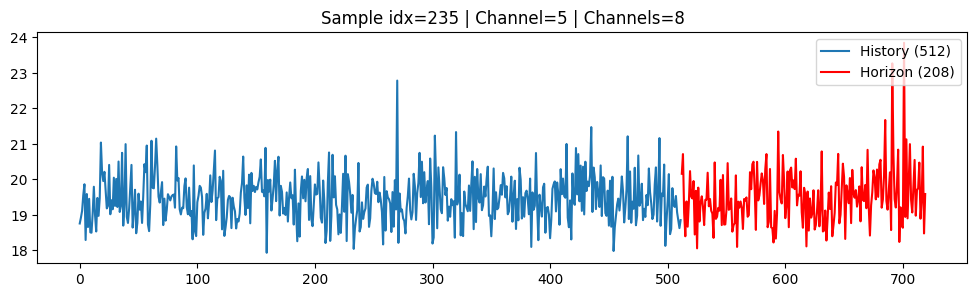

In [27]:
idx = np.random.randint(0, len(test_dataset))
sample_x, sample_mask, sample_y = test_dataset[idx]  

if torch.is_tensor(sample_x):
    sample_x = sample_x.cpu().numpy()
if torch.is_tensor(sample_y):
    sample_y = sample_y.cpu().numpy()

if sample_x.ndim == 1:
    C = 1
    channel_idx = 0
    x_plot = sample_x            
    y_plot = sample_y            
else:
    C = sample_x.shape[0]
    channel_idx = np.random.randint(0, C)
    x_plot = sample_x[channel_idx]   
    y_plot = sample_y[channel_idx]   

history_len = x_plot.shape[0]
horizon_len = y_plot.shape[0]

plt.figure(figsize=(12, 3))
plt.plot(np.arange(history_len), x_plot, label=f'History ({history_len})')
plt.plot(np.arange(history_len, history_len + horizon_len),y_plot, color='red', label=f'Horizon ({horizon_len})')
plt.title(f'Sample idx={idx} | Channel={channel_idx} | Channels={C}')
plt.legend(loc="upper right")
plt.show()


In [28]:
VARIANT_TO_MODEL = {
    "small": "AutonLab/MOMENT-1-small",
    "base":  "AutonLab/MOMENT-1-base",
    "large": "AutonLab/MOMENT-1-large",
}

VARIANT_TO_CHECKPOINT = {
    "small": "../data/checkpoints/small/TimeRAN_small.pth",
    "base":  "../data/checkpoints/base/TimeRAN_base.pth",
    "large": "../data/checkpoints/large/TimeRAN_large.pth",
}

variant = cfg["variant"].lower()
BACKEND = cfg["backend"]

if variant not in VARIANT_TO_MODEL:
    raise ValueError(f"Unknown variant '{cfg['variant']}'. Choose from {list(VARIANT_TO_MODEL.keys())}")

if BACKEND not in ["TimeRAN", "MOMENT"]:
    raise ValueError("backend must be either 'TimeRAN' or 'MOMENT'")

MODEL_NAME = VARIANT_TO_MODEL[variant]

model = MOMENTPipeline.from_pretrained(
    MODEL_NAME,
    model_kwargs={
        "task_name": "forecasting",
        "forecast_horizon": dataset_cfg["horizon"],
        "freeze_encoder": True if args.lora else (False if args.mode == "full_finetuning" else True),
        "freeze_embedder": True if args.lora else (False if args.mode == "full_finetuning" else True),
        "freeze_head": False
    }
)

model.init()

if BACKEND == "TimeRAN":
    CHECKPOINT_PATH = VARIANT_TO_CHECKPOINT[variant]

    print(f"Loading backbone: {MODEL_NAME}")
    print(f"Loading local checkpoint: {CHECKPOINT_PATH}")

    state_dict = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=True)

    if any(k.startswith("module.") for k in state_dict.keys()):
        state_dict = {k.replace("module.", "", 1): v for k, v in state_dict.items()}

    for k in ["head.linear.weight", "head.linear.bias"]:
        state_dict.pop(k, None)

elif BACKEND == "MOMENT":
    print(f"Using Hugging Face pretrained MOMENT weights only: {MODEL_NAME}")

else:
    raise ValueError(f"Unknown backend: {BACKEND}")

model = model.to(device)

Loading backbone: AutonLab/MOMENT-1-base
Loading local checkpoint: ../data/checkpoints/base/TimeRAN_base.pth


In [29]:
if args.lora and (args.mode == "full_finetuning"):
    print("LoRA enabled for MOMENT encoder")

    lora_config = LoraConfig(
        r=64,
        lora_alpha=32,
        lora_dropout=0.1,
        bias="none",
        target_modules=["q", "k", "v", "o", "wi_0", "wi_1", "wo"],
        task_type="FEATURE_EXTRACTION"
    )

    model.encoder = get_peft_model(model.encoder, lora_config)
    model.encoder.print_trainable_parameters()

In [30]:
trainable_params = []
frozen_params = []

for name, p in model.named_parameters():
    if p.requires_grad:
        trainable_params.append(name)
    else:
        frozen_params.append(name)

print("\n===== PARAMETER STATS =====")
print(f"Total parameters     : {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Frozen parameters    : {sum(p.numel() for p in model.parameters() if not p.requires_grad):,}")


===== PARAMETER STATS =====
Total parameters     : 119,859,280
Trainable parameters : 119,859,280
Frozen parameters    : 0


In [31]:
criterion = torch.nn.MSELoss().to(device)  
optimizer = torch.optim.Adam(model.parameters(), lr=float(args.init_lr))
scheduler = OneCycleLR(optimizer, max_lr=float(args.max_lr), total_steps= len(train_dataloader) * args.epochs, pct_start=0.3)
scaler = amp.GradScaler()

In [ ]:
all_train_losses = []
all_test_mse = []
all_test_mae = []

for epoch in range(args.epochs):
    model.train()
    train_losses = []

    pbar = tqdm(train_dataloader, total=len(train_dataloader), desc=f"Epoch {epoch+1}/{args.epochs} [train]")
    for timeseries, input_mask, forecast in pbar:

        timeseries = timeseries.float()
        forecast   = forecast.float()

        if timeseries.ndim == 2:  
            timeseries = timeseries.unsqueeze(1)

        if forecast.ndim == 2:     
            forecast = forecast.unsqueeze(1)

        timeseries = timeseries.to(device)  
        forecast   = forecast.to(device)     
        input_mask = input_mask.to(device)   

        optimizer.zero_grad(set_to_none=True)

        with amp.autocast():
            out = model(x_enc=timeseries, input_mask=input_mask)
            loss = criterion(out.forecast, forecast)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), args.max_norm)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        train_losses.append(loss.item())
        pbar.set_postfix({"loss": np.mean(train_losses)})

    epoch_train_mse = float(np.mean(train_losses))
    all_train_losses.append(epoch_train_mse)
    print(f"Epoch {epoch+1}: Train MSE: {epoch_train_mse:.4f}")

    model.eval()
    test_losses = []
    trues, preds, histories = [], [], []

    with torch.no_grad():
        pbar_test = tqdm(test_dataloader, total=len(test_dataloader), desc=f"Epoch {epoch+1}/{args.epochs} [test]")
        for timeseries, input_mask, forecast in pbar_test:

            timeseries = timeseries.float()
            forecast   = forecast.float()

            if timeseries.ndim == 2:
                timeseries = timeseries.unsqueeze(1)

            if forecast.ndim == 2:
                forecast = forecast.unsqueeze(1)

            timeseries = timeseries.to(device)
            forecast   = forecast.to(device)
            input_mask = input_mask.to(device)

            with amp.autocast():
                out = model(x_enc=timeseries, input_mask=input_mask)
                loss = criterion(out.forecast, forecast)

            test_losses.append(loss.item())
            trues.append(forecast.detach().cpu().numpy())
            preds.append(out.forecast.detach().cpu().numpy())
            histories.append(timeseries.detach().cpu().numpy())

    test_losses = np.array(test_losses)
    print(f"Epoch {epoch+1}: Test MSE (avg batch loss): {np.mean(test_losses):.4f}")

    trues = np.concatenate(trues, axis=0)          
    preds = np.concatenate(preds, axis=0)          
    histories = np.concatenate(histories, axis=0)  

    metrics = get_forecasting_metrics(y=trues, y_hat=preds, reduction="mean")
    all_test_mse.append(float(metrics.mse))
    all_test_mae.append(float(metrics.mae))

    print(f"Epoch {epoch+1}: Test MSE: {metrics.mse:.4f} | Test MAE: {metrics.mae:.4f}")

Epoch 1/5 [train]: 100%|██████████| 43/43 [00:21<00:00,  2.02it/s, loss=13.6]


Epoch 1: Train MSE: 13.5820


Epoch 1/5 [test]: 100%|██████████| 19/19 [00:02<00:00,  8.88it/s]


Epoch 1: Test MSE (avg batch loss): 8.8611
Epoch 1: Test MSE: 8.7880 | Test MAE: 0.7759


Epoch 2/5 [train]: 100%|██████████| 43/43 [00:21<00:00,  2.03it/s, loss=12.1]


...

Epoch 4: Test MSE (avg batch loss): 8.4143
Epoch 4: Test MSE: 8.3231 | Test MAE: 0.7691


Epoch 5/5 [train]: 100%|██████████| 43/43 [00:21<00:00,  2.03it/s, loss=8.04]


Epoch 5: Train MSE: 8.0404


Epoch 5/5 [test]: 100%|██████████| 19/19 [00:02<00:00,  8.91it/s]

Epoch 5: Test MSE (avg batch loss): 8.4665
Epoch 5: Test MSE: 8.3791 | Test MAE: 0.7759


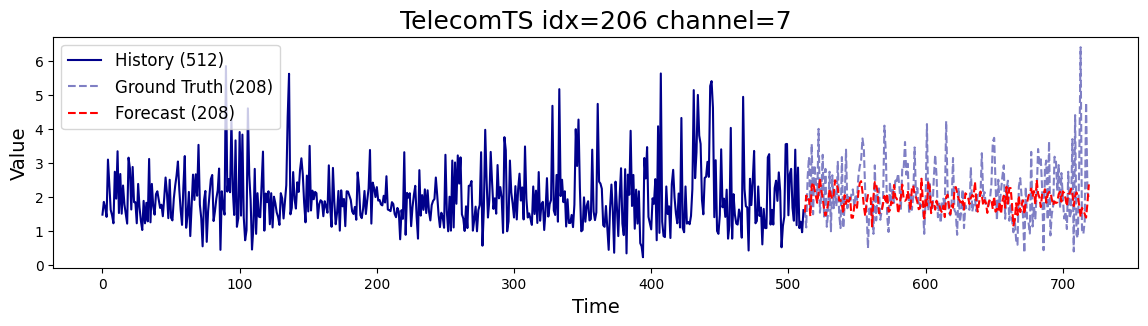

In [40]:
time_index = np.random.randint(0, trues.shape[0])
channel_idx = np.random.randint(0, trues.shape[1]) if trues.shape[1] > 1 else 0

history = histories[time_index, channel_idx, :]
true = trues[time_index, channel_idx, :]
pred = preds[time_index, channel_idx, :]

plt.figure(figsize=(14, 3))
plt.plot(np.arange(len(history)), history, label=f"History ({dataset_cfg['seq_len']})", color="darkblue")
offset = len(history)
plt.plot(np.arange(offset, offset + len(true)), true, label=f"Ground Truth ({dataset_cfg['horizon']})", color="darkblue", linestyle="--", alpha=0.5)
plt.plot(np.arange(offset, offset + len(pred)), pred, label=f"Forecast ({dataset_cfg['horizon']})", color="red", linestyle="--")
plt.title(f"{dataset_cfg['class']} idx={time_index} channel={channel_idx}", fontsize=18)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Value', fontsize=14)
plt.legend(fontsize=12)
plt.show()
